# Comparison: Popular (Overall) vs Random

In this notebook, we compare two non-personalized baselines:
- **PopularGlobal** (most popular overall)
- **RandomNormal**

We compare only the required metrics:
- Accuracy@K
- NDCG@K
- Diversity
- Personalisation
- Coverage


## 1) Setup and loading saved summaries

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)


In [2]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for c in [start, *start.parents]:
        if (c / 'dataset').exists() and (c / 'non_personalised_recommenders').exists():
            return c
    raise FileNotFoundError('Project root not found')

PROJECT_ROOT = find_project_root(Path.cwd())
RESULTS_DIR = PROJECT_ROOT / 'data' / 'results'

popular_summary_path = RESULTS_DIR / 'nonpers_popular_summary.csv'
random_summary_path = RESULTS_DIR / 'nonpers_random_summary.csv'

print('popular summary:', popular_summary_path)
print('random summary:', random_summary_path)


popular summary: /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system/data/results/nonpers_popular_summary.csv
random summary: /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system/data/results/nonpers_random_summary.csv


In [3]:
popular_summary = pd.read_csv(popular_summary_path, index_col=0)
random_summary = pd.read_csv(random_summary_path, index_col=0)

print('popular_summary shape:', popular_summary.shape)
print('random_summary shape:', random_summary.shape)

display(popular_summary.head())
display(random_summary.head())


popular_summary shape: (3, 11)
random_summary shape: (1, 11)


,Accuracy@5,Accuracy@10,Accuracy@20,NDCG@5,NDCG@10,NDCG@20,Diversity@5,Diversity@10,Diversity@20,Personalisation@10,Coverage
PopularGlobal,0.00468,0.00400,0.00315,0.006596,0.008424,0.010756,0.698213,0.665846,0.639617,0.025232,0.000169
PopularByCountry,0.01004,0.00802,0.00594,0.015353,0.018864,0.022558,0.123600,0.112646,0.118425,0.857921,0.003070
PopularByType,0.00412,0.00374,0.00328,0.005723,0.007598,0.010558,0.528560,0.574987,0.548592,0.199982,0.000755


,Accuracy@5,Accuracy@10,Accuracy@20,NDCG@5,NDCG@10,NDCG@20,Diversity@5,Diversity@10,Diversity@20,Personalisation@10,Coverage
RandomNormal,0.0,0.00002,0.00004,0.0,0.000026,0.000098,0.76272,0.763496,0.765735,0.998543,0.061542


## 2) Keep only Popular Global and align required metrics

In [4]:
required_metrics = [
    'Accuracy@10',
    'NDCG@10',
    'Diversity@10',
    'Personalisation@10',
    'Coverage'
]

if 'PopularGlobal' not in popular_summary.index:
    raise ValueError('PopularGlobal row not found in nonpers_popular_summary.csv')

if 'RandomNormal' not in random_summary.index:
    # fallback to first row if index label changed
    print('RandomNormal index not found, using first row from random summary.')
    random_row = random_summary.iloc[[0]].copy()
    random_row.index = ['RandomNormal']
else:
    random_row = random_summary.loc[['RandomNormal']].copy()

popular_row = popular_summary.loc[['PopularGlobal']].copy()

comparison = pd.concat([popular_row, random_row], axis=0)
comparison = comparison[[m for m in required_metrics if m in comparison.columns]].copy()

display(comparison)


,Accuracy@10,NDCG@10,Diversity@10,Personalisation@10,Coverage
PopularGlobal,0.00400,0.008424,0.665846,0.025232,0.000169
RandomNormal,0.00002,0.000026,0.763496,0.998543,0.061542


## 3) Metric comparison plots

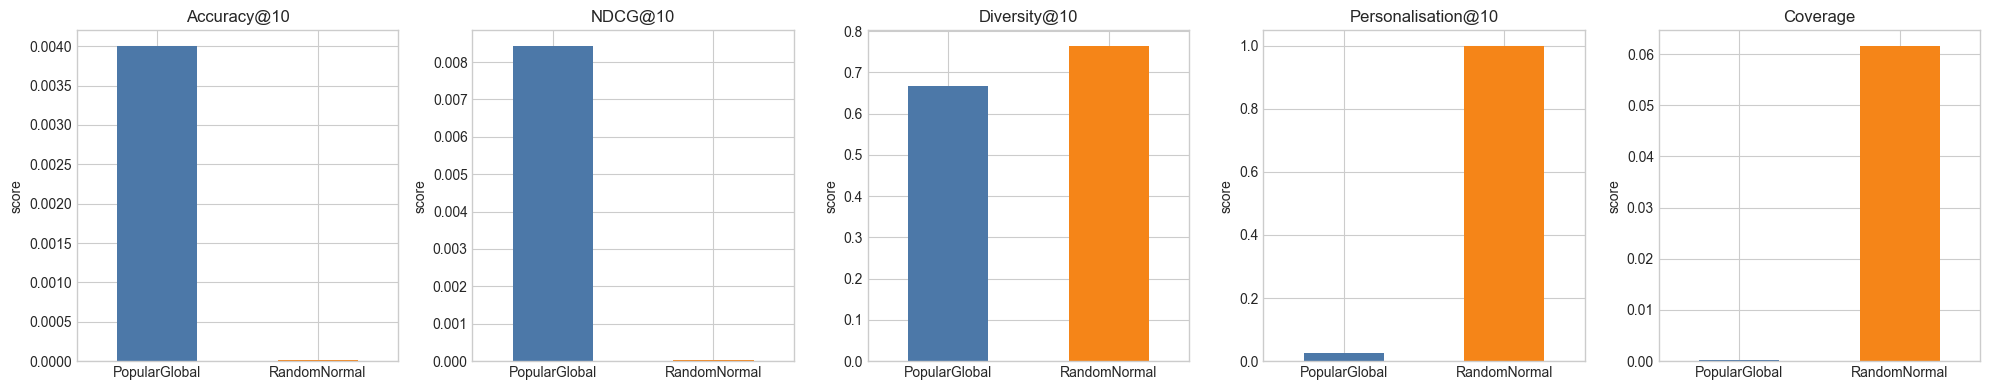

In [6]:
plot_df = comparison.T.copy()

fig, axes = plt.subplots(1, len(plot_df.index), figsize=(4 * len(plot_df.index), 4))
if len(plot_df.index) == 1:
    axes = [axes]

for ax, metric in zip(axes, plot_df.index):
    vals = plot_df.loc[metric]
    vals.plot(kind='bar', ax=ax, color=['#4C78A8', '#F58518'])
    ax.set_title(metric)
    ax.set_ylabel('score')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


These graphs show that the popular model clearly performs better in terms of accuracy and NDCG, meaning it gives more relevant recommendations than the Random model. This makes sense, because it uses popularity information, while the Random model does not learn anything meaningful.

On the other hand, the random model has higher diversity, personalisation, and coverage. However, these results are misleading. The very high personalisation is a false friend, since it only means users get different random items, not better or more accurate recommendations. Similarly, higher diversity and coverage come from randomness, not from a smart recommendation strategy.

Overall, this comparison shows that while the random model looks better in some metrics, the Popular Global model is actually more useful, because it provides more accurate and meaningful recommendations.


## 4) Save comparison table

In [8]:
compare_path = RESULTS_DIR / 'nonpers_popularglobal_vs_random_comparison.csv'
comparison.to_csv(compare_path)
print('Saved:', compare_path)


Saved: /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system/data/results/nonpers_popularglobal_vs_random_comparison.csv
